In [ ]:
import pandas as pd

In [ ]:
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

In [ ]:
df = pd.read_csv('./data/adult.data', names=columns, skipinitialspace=True)

In [ ]:
df.head()

### Task 1: Understanding the data

In [ ]:
df.info()

In [ ]:
df.isnull().sum()

# Inter: No null values

In [ ]:
df.duplicated().sum()
# Inter; 24 duplicated values

In [ ]:
df[
    [
        'age',
        'fnlwgt',
        'education-num',
        'capital-gain',
        'capital-loss',
        'hours-per-week',
        'income',
    ]
].info()

In [ ]:
df[
    [
        'workclass',
        'education',
        'marital-status',
        'occupation',
        'relationship',
        'race',
        'sex',
        'native-country',        
    ]
].info()

### Report

```
# Initial Interpretation
# 1) Data has 
    # 15 columns
    # 32560 rows

# 2) Null -> False

# 3) Duplicate -> 24

# 4) Categorical Columns (str)
    # workclass
    # education
    # marital-status
    # occupation
    # relationship
    # race
    # sex
    # native-country

# 5) Numerical Columns
    # age
    # fnlwgt
    # education-num
    # capital-gain
    # capital-loss
    # hours-per-week

    # income (dtype str)

### Task 2: Data cleaning

In [ ]:
# questions
    # Remove duplicate rows

In [ ]:
df = df.drop_duplicates()
df.shape

# Removed rows 24

### Task 3: EDA

In [ ]:
# EDA Task strategy
# 1) Identify the relationship with education and education-num
# 2) Compare features with target


# EDA Report
# 1) Relationship between(education, education-num): Education num is the number associated to the
    # Education class e.g Preschool = 1, 1st-4th = 2, HS-grad = 9, Doctorate = 16


#### Task 1: Identify relationship between education and education-num

In [ ]:

# df[['education', 'education-num']].drop_duplicates().sort_values('education-num')

<!-- #### Task 2: Relationship of feature with the target -->

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

<!-- ```3 Cases

i) Numerical feature vs Categorical target EDA
ii) Categorical feature vs Categorical target EDA
iii)Numerical feature vs Numerical feature EDA -->

<!-- ##### 1) Numerical Feature vs Categorical Target EDA -->

<!-- **1) Age vs Income** -->

In [ ]:
# df.groupby('income')['age'].describe().T

# # pd.pivot_table(
# #     df,
# #     values='age',
# #     index='income',
# #     aggfunc=['count', 'mean','std','min','max']
# # ).T

In [ ]:

# sns.boxplot(x='income', y='age', data=df)
# plt.show()

# # Interpretation: the age distribution of the two income groups is shifted: the >50k group has a noticably
# # higher median and quatiles than the <=50k group

# # Also many values from both income groups has an overlap of age

<!-- **2) Hours-per-week vs Income** -->

In [ ]:
# df.groupby('hours-per-week')['income'].value_counts()

# pd.crosstab(
#     df,
#     df['hours-per-week'],
#     df['income'],
#     normalize='index'
# )

<!-- ##### 2) Categorical feature vs Categorical target EDA -->

In [ ]:
# # Education Groupby and per income ratio

# pd.crosstab(
#     df['education'],
#     df['income'],
#     normalize='index'
# ).mul(100).round(2)


# # Interpretation: As education increases the income also increases.
# # most people has less education such as 10th, 11th, 7th, preschool
# # are earning less than 50k
# # Higher educated people are mostly earning higher income

---

### Task 3: EDA

``` Strategy:
    Analysis types: 
        Num-Num
        Num-Category
        Category-Num
        
    1) Feature Analysis: 
        1) Univariate Analysis
        2) Bivariate Analysis
        3) Multivariate Analysis
    2) Target Analysis: Categorical Variable

#### 1: Feature Analysis

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

##### Number Analysis
**age**<br>
**fnlwgt**<br>
**education-num**<br>
**capital-gain**<br>
**capital-loss**<br>
**hours-per-week**

count    32537.000000
mean        38.585549
std         13.637984
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64


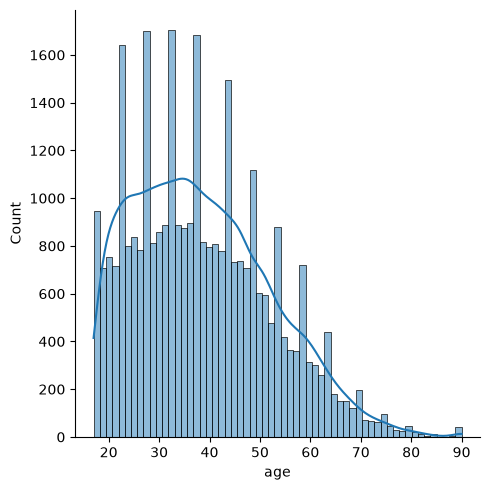

In [ ]:
# 1) Age Analysis
print(df.age.describe())
sns.displot(df.age, kde=True)
plt.show()


# Interpretation
"""
Age:
- Range: 17-90
- Median: 37
- Middle 50%: 28-48
- Slight/moderate right skew
- No obviously impossible values
"""


Fnlwgt:
- Mean: 189780.8
- Median: 178356.0
- Range: 12285.0-1484705.0
- Middle 50%: 117827.0-236993.0
- Spread IQR: 119166.0
- Compare: Mean > Median -> Right skewness
- Extreme values: Investigate rather than automatically remove



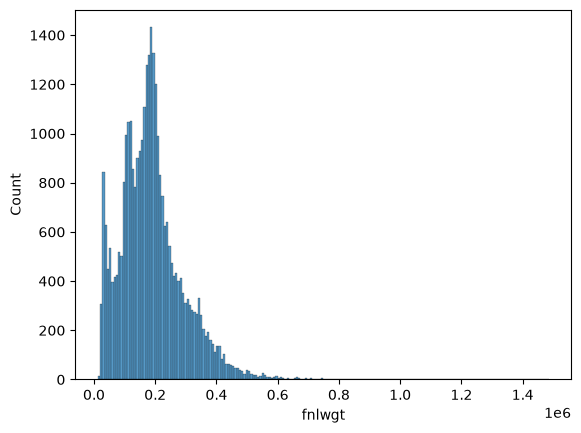

In [91]:
# fnlwgt
fnlwgtNumSum = df.fnlwgt.describe()
# print(fnlwgtNumSum)
IQR = fnlwgtNumSum['75%'] - fnlwgtNumSum['25%']
IQR

# Interpretation
print(f"""
Fnlwgt:
- Mean: {round(fnlwgtNumSum['mean'],1)}
- Median: {fnlwgtNumSum['50%']}
- Range: {fnlwgtNumSum['min']}-{fnlwgtNumSum['max']}
- Middle 50%: {fnlwgtNumSum['25%']}-{fnlwgtNumSum['75%']}
- Spread IQR: {IQR}
- Compare: Mean > Median -> Right skewness
- Extreme values: Investigate rather than automatically remove
""")

# Histogram
sns.histplot(df['fnlwgt'])
plt.show()

                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  32537.000000  3.253700e+04   32537.000000  32537.000000  32537.000000   
mean      38.585549  1.897808e+05      10.081815   1078.443741     87.368227   
std       13.637984  1.055565e+05       2.571633   7387.957424    403.101833   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.369930e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours-per-week  
count    32537.000000  
mean        40.440329  
std         12.346889  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  

hours-per-week
Null: 0
Mean: 40.44
Median: 40.00

25%: 40.00
5

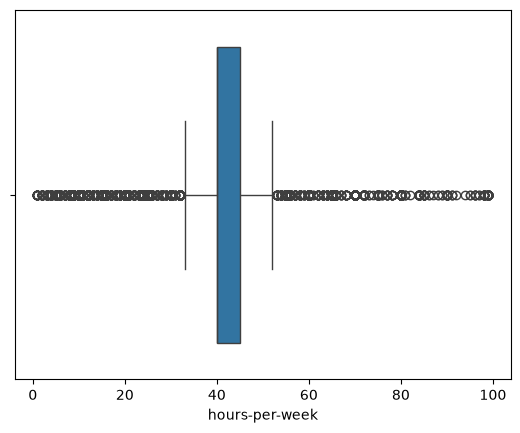

In [125]:
print(df.describe())

# Interpretation
print("""
hours-per-week
Null: 0
Mean: 40.44
Median: 40.00

25%: 40.00
50%: 40.00
75%: 45

Mean approx Median
Center concentrated graph
25% and 50% quartiles have same numbers
so 50% people work <= 40 hours same as 25%
75% people work <=45 hours

so very few people are on both ends
who works very few hours and more hours. so they could be possible outliers
""")


sns.boxplot(x=df['hours-per-week'])
plt.show()
